# 07c — EGF–EGFR MD Interface Persistence and F0010 Source-Region Analysis

## Pipeline 3 — Molecular Dynamics and Binding-Energy Analysis

This notebook integrates the **dynamic interface information** obtained in:

```text
07b_EGFR_Dimer_MD_Contact_Persistence.ipynb


## 1. Imports

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Imports OK")


Imports OK


## 2. Configuration

In [2]:
# ------------------------------------------------------
# 07b outputs
# ------------------------------------------------------
RUN_LABEL = "production_1ns"

INPUT_07B = (
    Path("outputs")
    / "pipeline_3_md_07b_contact_persistence"
    / RUN_LABEL
)

ANALYSIS_07B = INPUT_07B / "analysis"

CONTACTS_CSV = (
    ANALYSIS_07B
    / "BD_contact_persistence.csv"
)

PERSISTENT_CONTACTS_CSV = (
    ANALYSIS_07B
    / "BD_persistent_contacts_50pct.csv"
)

B_RESIDUE_CSV = (
    ANALYSIS_07B
    / "chain_B_residue_contact_persistence.csv"
)

D_RESIDUE_CSV = (
    ANALYSIS_07B
    / "chain_D_residue_contact_persistence.csv"
)

RMSF_CSV = (
    ANALYSIS_07B
    / "rmsf_ca_by_residue.csv"
)

SUMMARY_07B_CSV = (
    ANALYSIS_07B
    / "07b_summary_metrics.csv"
)

# ------------------------------------------------------
# Pipeline 1/2 energetic hotspot files
# ------------------------------------------------------
# The notebook searches several common PEARL output paths automatically.
HOTSPOT_CANDIDATES = [
    Path("outputs/energetic_hotspots.csv"),
    Path("outputs/interface_residues_with_foldx_ddg.csv"),
    Path("outputs/energetic_contiguous_windows_ranked.csv"),
    Path("outputs/pipeline_1_initial_prototype/energetic_hotspots.csv"),
    Path("outputs/pipeline_2_structural_validation_and_docking/energetic_hotspots.csv"),
]

# ------------------------------------------------------
# Biological definitions
# ------------------------------------------------------
CHAIN_B = "B"
CHAIN_D = "D"

F0010_SEQUENCE = "IGERCQYRDLK"
F0010_START_RESID = 38
F0010_END_RESID = 48

PERSISTENCE_THRESHOLD = 0.50
HIGH_PERSISTENCE_THRESHOLD = 0.80

# FoldX hotspot threshold used in previous PEARL stages
FOLDX_HOTSPOT_THRESHOLD = 1.5

# ------------------------------------------------------
# Output
# ------------------------------------------------------
OUTPUT_DIR = (
    Path("outputs")
    / "pipeline_3_md_07c_hotspot_interface_validation"
)

TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"

for d in [OUTPUT_DIR, TABLE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("07b input:", INPUT_07B.resolve())
print("Output:", OUTPUT_DIR.resolve())


07b input: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07b_contact_persistence/production_1ns
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07c_hotspot_interface_validation


## 3. Check required 07b files

In [3]:
required_files = [
    CONTACTS_CSV,
    PERSISTENT_CONTACTS_CSV,
    B_RESIDUE_CSV,
    D_RESIDUE_CSV,
    RMSF_CSV,
    SUMMARY_07B_CSV,
]

checks = pd.DataFrame([
    {
        "file": str(path),
        "exists": path.exists(),
        "size_kB": path.stat().st_size / 1024 if path.exists() else np.nan,
    }
    for path in required_files
])

display(checks)

if not checks["exists"].all():
    missing = checks.loc[~checks["exists"], "file"].tolist()
    raise FileNotFoundError(
        "Missing required 07b files:\n" + "\n".join(missing)
    )

print("07b input check: PASS")


,file,exists,size_kB
0,outputs/pipeline_3_md_07b_contact_persistence/...,True,8.346680
1,outputs/pipeline_3_md_07b_contact_persistence/...,True,4.572266
2,outputs/pipeline_3_md_07b_contact_persistence/...,True,1.319336
3,outputs/pipeline_3_md_07b_contact_persistence/...,True,0.951172
4,outputs/pipeline_3_md_07b_contact_persistence/...,True,18.447266
5,outputs/pipeline_3_md_07b_contact_persistence/...,True,0.639648


07b input check: PASS


## 4. Load MD contact-persistence results

In [4]:
contact_df = pd.read_csv(CONTACTS_CSV)
persistent_contact_df = pd.read_csv(PERSISTENT_CONTACTS_CSV)
B_residue_df = pd.read_csv(B_RESIDUE_CSV)
D_residue_df = pd.read_csv(D_RESIDUE_CSV)
rmsf_df = pd.read_csv(RMSF_CSV)
summary_07b_df = pd.read_csv(SUMMARY_07B_CSV)

print("All contacts:", len(contact_df))
print("Persistent contacts >=50%:", len(persistent_contact_df))
print("B dynamic residues:", len(B_residue_df))
print("D dynamic residues:", len(D_residue_df))

display(contact_df.head(10))


All contacts: 144
Persistent contacts >=50%: 78
B dynamic residues: 54
D dynamic residues: 37


,B_resname,B_resid,D_resname,D_resid,frames_in_contact,n_frames,persistence,persistence_percent,mean_min_distance_A,persistent_50pct
0,ASP,355,ARG,41,500,500,1.0,100.0,2.748417,True
1,GLN,411,LYS,48,500,500,1.0,100.0,2.835348,True
2,GLN,16,CYS,31,500,500,1.0,100.0,2.933767,True
3,GLN,16,CYS,33,500,500,1.0,100.0,3.026353,True
4,ARG,29,TRP,49,500,500,1.0,100.0,3.135729,True
5,GLN,384,ARG,45,500,500,1.0,100.0,3.146737,True
6,GLN,16,ASN,32,500,500,1.0,100.0,3.288483,True
7,LEU,348,GLN,43,500,500,1.0,100.0,3.419805,True
8,THR,15,CYS,31,500,500,1.0,100.0,3.434341,True
9,THR,15,GLU,40,500,500,1.0,100.0,3.448216,True


## 5. Identify the hotspot table automatically

In [5]:
existing_hotspot_files = [
    path
    for path in HOTSPOT_CANDIDATES
    if path.exists()
]

print("Candidate hotspot files found:")
for path in existing_hotspot_files:
    print(" ", path)

HOTSPOT_FILE = (
    existing_hotspot_files[0]
    if existing_hotspot_files
    else None
)

if HOTSPOT_FILE is None:
    print(
        "\nNo hotspot CSV was found automatically.\n"
        "The MD-only sections of the notebook will still run.\n"
        "Set HOTSPOT_FILE manually to the FoldX hotspot CSV before "
        "running the integration sections."
    )
else:
    print("\nUsing hotspot file:", HOTSPOT_FILE)


Candidate hotspot files found:
  outputs/energetic_hotspots.csv
  outputs/interface_residues_with_foldx_ddg.csv
  outputs/energetic_contiguous_windows_ranked.csv

Using hotspot file: outputs/energetic_hotspots.csv


## 6. Flexible hotspot-table parser

Earlier PEARL notebooks may use slightly different column names.

This parser attempts to identify:

- chain;
- residue number;
- residue name;
- FoldX ΔΔG;
- hotspot flag.

If the automatic parser cannot identify the required fields, it will show the available columns instead of guessing.


In [6]:
hotspot_df = None
hotspot_columns_detected = {}

def find_column(columns, candidates):
    lower_map = {
        str(c).lower(): c
        for c in columns
    }

    for candidate in candidates:
        for lower_name, original in lower_map.items():
            if candidate.lower() == lower_name:
                return original

    for candidate in candidates:
        for lower_name, original in lower_map.items():
            if candidate.lower() in lower_name:
                return original

    return None

if HOTSPOT_FILE is not None:
    raw_hotspot_df = pd.read_csv(HOTSPOT_FILE)

    print("Hotspot columns:")
    print(list(raw_hotspot_df.columns))

    chain_col = find_column(
        raw_hotspot_df.columns,
        ["chain", "chain_id"]
    )

    resid_col = find_column(
        raw_hotspot_df.columns,
        [
            "resseq",
            "resid",
            "residue_number",
            "residue_id",
        ]
    )

    resname_col = find_column(
        raw_hotspot_df.columns,
        [
            "resname",
            "residue_name",
            "aa",
        ]
    )

    ddg_col = find_column(
        raw_hotspot_df.columns,
        [
            "ddg",
            "ddg_kcal_mol",
            "foldx_ddg",
            "alanine_scan_ddg_kcal_mol",
        ]
    )

    hotspot_flag_col = find_column(
        raw_hotspot_df.columns,
        [
            "is_hotspot",
            "hotspot",
            "energetic_hotspot",
        ]
    )

    hotspot_columns_detected = {
        "chain": chain_col,
        "resid": resid_col,
        "resname": resname_col,
        "ddg": ddg_col,
        "hotspot_flag": hotspot_flag_col,
    }

    print("\nDetected:")
    display(pd.DataFrame(
        list(hotspot_columns_detected.items()),
        columns=["role", "column"]
    ))

    if chain_col is not None and resid_col is not None:
        hotspot_df = pd.DataFrame({
            "chain": raw_hotspot_df[chain_col].astype(str),
            "resid": pd.to_numeric(
                raw_hotspot_df[resid_col],
                errors="coerce",
            ),
        })

        if resname_col is not None:
            hotspot_df["resname"] = (
                raw_hotspot_df[resname_col]
                .astype(str)
            )
        else:
            hotspot_df["resname"] = None

        if ddg_col is not None:
            hotspot_df["foldx_ddG_kcal_mol"] = pd.to_numeric(
                raw_hotspot_df[ddg_col],
                errors="coerce",
            )
        else:
            hotspot_df["foldx_ddG_kcal_mol"] = np.nan

        if hotspot_flag_col is not None:
            hotspot_df["is_foldx_hotspot"] = (
                raw_hotspot_df[hotspot_flag_col]
                .astype(bool)
            )
        elif ddg_col is not None:
            hotspot_df["is_foldx_hotspot"] = (
                hotspot_df["foldx_ddG_kcal_mol"]
                > FOLDX_HOTSPOT_THRESHOLD
            )
        else:
            hotspot_df["is_foldx_hotspot"] = False

        hotspot_df = hotspot_df.dropna(subset=["resid"]).copy()
        hotspot_df["resid"] = hotspot_df["resid"].astype(int)

        hotspot_df = (
            hotspot_df
            .drop_duplicates(
                subset=["chain", "resid"]
            )
            .reset_index(drop=True)
        )

        print("\nNormalized hotspot table:")
        display(hotspot_df.head(20))
    else:
        print(
            "\nCould not identify chain/residue columns automatically."
        )


Hotspot columns:
['chain', 'resseq', 'resname', 'node', 'aa1', 'n_contacts', 'degree', 'betweenness', 'graph_proxy_score', 'foldx_buildmodel_mutation', 'scan_required', 'ddG_kcal_mol', 'source_file', 'raw_line', 'has_foldx_ddg', 'is_energetic_hotspot', 'is_graph_proxy_hotspot_like']

Detected:


,role,column
0,chain,chain
1,resid,resseq
2,resname,resname
3,ddg,ddG_kcal_mol
4,hotspot_flag,is_energetic_hotspot



Normalized hotspot table:


,chain,resid,resname,foldx_ddG_kcal_mol,is_foldx_hotspot
0,D,45,ARG,2.00281,True
1,D,33,CYS,2.91303,True
2,D,43,GLN,2.51557,True
3,D,26,LEU,4.15852,True
4,D,23,ILE,3.65614,True
5,D,41,ARG,5.73455,True
6,D,39,GLY,5.87659,True
7,D,16,HIS,2.44148,True
8,D,47,LEU,3.54371,True
9,D,44,TYR,3.37068,True


## 7. Dynamic residue support from MD

In [7]:
def prepare_dynamic_residue_table(
    residue_df,
    chain_id,
    resid_col,
    resname_col,
):
    out = residue_df.copy()

    out = out.rename(columns={
        resid_col: "resid",
        resname_col: "resname",
    })

    out["chain"] = chain_id

    out["dynamic_contact_support"] = pd.cut(
        out["max_contact_persistence"],
        bins=[-np.inf, 0.25, 0.50, 0.80, np.inf],
        labels=[
            "low",
            "moderate",
            "persistent",
            "very_persistent",
        ],
    )

    return out

B_dynamic = prepare_dynamic_residue_table(
    B_residue_df,
    CHAIN_B,
    "B_resid",
    "B_resname",
)

D_dynamic = prepare_dynamic_residue_table(
    D_residue_df,
    CHAIN_D,
    "D_resid",
    "D_resname",
)

dynamic_residue_df = pd.concat(
    [B_dynamic, D_dynamic],
    ignore_index=True,
)

dynamic_residue_df.to_csv(
    TABLE_DIR / "dynamic_interface_residue_support.csv",
    index=False,
)

print("Top dynamic residues:")
display(
    dynamic_residue_df
    .sort_values(
        "max_contact_persistence",
        ascending=False,
    )
    .head(30)
)


Top dynamic residues:


,resid,resname,max_contact_persistence,mean_contact_persistence,n_partner_residues,chain,dynamic_contact_support
0,325,LEU,1.000,0.785000,4,B,very_persistent
54,32,ASN,1.000,0.457000,4,D,very_persistent
56,43,GLN,1.000,0.754500,4,D,very_persistent
57,41,ARG,1.000,0.644333,6,D,very_persistent
58,40,GLU,1.000,0.931500,4,D,very_persistent
59,47,LEU,1.000,0.650222,9,D,very_persistent
1,29,ARG,1.000,0.472000,4,B,very_persistent
60,33,CYS,1.000,0.767500,4,D,very_persistent
61,31,CYS,1.000,0.716000,3,D,very_persistent
62,45,ARG,1.000,0.465429,7,D,very_persistent


## 8. Add RMSF to dynamic residue support

In [8]:
rmsf_norm = rmsf_df.copy()

rmsf_norm = rmsf_norm.rename(columns={
    "chain": "chain",
    "resid": "resid",
    "resname": "rmsf_resname",
    "rmsf_A": "CA_RMSF_A",
})

dynamic_with_rmsf_df = dynamic_residue_df.merge(
    rmsf_norm[
        [
            "chain",
            "resid",
            "CA_RMSF_A",
        ]
    ],
    on=["chain", "resid"],
    how="left",
)

dynamic_with_rmsf_df.to_csv(
    TABLE_DIR / "dynamic_interface_with_rmsf.csv",
    index=False,
)

display(
    dynamic_with_rmsf_df
    .sort_values(
        [
            "max_contact_persistence",
            "CA_RMSF_A",
        ],
        ascending=[False, True],
    )
    .head(30)
)


,resid,resname,max_contact_persistence,mean_contact_persistence,n_partner_residues,chain,dynamic_contact_support,CA_RMSF_A
6,412,PHE,1.000,0.960000,2,B,very_persistent,0.554718
8,438,ILE,1.000,1.000000,1,B,very_persistent,0.585636
9,411,GLN,1.000,1.000000,1,B,very_persistent,0.622642
59,47,LEU,1.000,0.650222,9,D,very_persistent,0.623343
57,41,ARG,1.000,0.644333,6,D,very_persistent,0.661158
2,384,GLN,1.000,0.954400,5,B,very_persistent,0.663582
58,40,GLU,1.000,0.931500,4,D,very_persistent,0.671631
0,325,LEU,1.000,0.785000,4,B,very_persistent,0.679301
64,48,LYS,1.000,0.727000,4,D,very_persistent,0.686453
11,15,THR,1.000,0.492000,10,B,very_persistent,0.691445


## 9. Integrate MD with FoldX hotspots

If a valid hotspot table was found, this section merges energetic and dynamic evidence.

The resulting table distinguishes:

```text
FoldX hotspot only
MD-persistent only
FoldX hotspot + MD persistent
neither
```


In [9]:
integrated_df = None

if hotspot_df is not None:
    integrated_df = dynamic_with_rmsf_df.merge(
        hotspot_df[
            [
                "chain",
                "resid",
                "foldx_ddG_kcal_mol",
                "is_foldx_hotspot",
            ]
        ],
        on=["chain", "resid"],
        how="outer",
    )

    integrated_df["max_contact_persistence"] = (
        integrated_df["max_contact_persistence"]
        .fillna(0.0)
    )

    integrated_df["is_md_persistent"] = (
        integrated_df["max_contact_persistence"]
        >= PERSISTENCE_THRESHOLD
    )

    integrated_df["is_md_very_persistent"] = (
        integrated_df["max_contact_persistence"]
        >= HIGH_PERSISTENCE_THRESHOLD
    )

    integrated_df["is_foldx_hotspot"] = (
        integrated_df["is_foldx_hotspot"]
        .fillna(False)
        .astype(bool)
    )

    def evidence_class(row):
        foldx = bool(row["is_foldx_hotspot"])
        mdp = bool(row["is_md_persistent"])

        if foldx and mdp:
            return "FoldX_hotspot_and_MD_persistent"
        if foldx:
            return "FoldX_hotspot_only"
        if mdp:
            return "MD_persistent_only"
        return "neither"

    integrated_df["evidence_class"] = (
        integrated_df.apply(
            evidence_class,
            axis=1,
        )
    )

    integrated_df.to_csv(
        TABLE_DIR
        / "FoldX_MD_integrated_residue_validation.csv",
        index=False,
    )

    print("Evidence classes:")
    display(
        integrated_df["evidence_class"]
        .value_counts()
        .rename_axis("class")
        .reset_index(name="count")
    )

    print(
        "\nResidues supported by both FoldX and MD:"
    )

    display(
        integrated_df[
            integrated_df["evidence_class"]
            == "FoldX_hotspot_and_MD_persistent"
        ]
        .sort_values(
            [
                "max_contact_persistence",
                "foldx_ddG_kcal_mol",
            ],
            ascending=[False, False],
        )
    )
else:
    print(
        "FoldX integration skipped because no hotspot table was loaded."
    )


Evidence classes:


,class,count
0,MD_persistent_only,49
1,neither,27
2,FoldX_hotspot_and_MD_persistent,15



Residues supported by both FoldX and MD:


,resid,resname,max_contact_persistence,mean_contact_persistence,n_partner_residues,chain,dynamic_contact_support,CA_RMSF_A,foldx_ddG_kcal_mol,is_foldx_hotspot,is_md_persistent,is_md_very_persistent,evidence_class
80,41,ARG,1.000,0.644333,6,D,very_persistent,0.661158,5.73455,True,True,True,FoldX_hotspot_and_MD_persistent
64,23,ILE,1.000,0.720000,4,D,very_persistent,0.999830,3.65614,True,True,True,FoldX_hotspot_and_MD_persistent
86,47,LEU,1.000,0.650222,9,D,very_persistent,0.623343,3.54371,True,True,True,FoldX_hotspot_and_MD_persistent
59,13,TYR,1.000,0.522000,2,D,very_persistent,0.852956,3.32989,True,True,True,FoldX_hotspot_and_MD_persistent
73,33,CYS,1.000,0.767500,4,D,very_persistent,0.762207,2.91303,True,True,True,FoldX_hotspot_and_MD_persistent
82,43,GLN,1.000,0.754500,4,D,very_persistent,0.766363,2.51557,True,True,True,FoldX_hotspot_and_MD_persistent
60,15,LEU,1.000,0.670000,4,D,very_persistent,0.785735,2.50159,True,True,True,FoldX_hotspot_and_MD_persistent
84,45,ARG,1.000,0.465429,7,D,very_persistent,0.877660,2.00281,True,True,True,FoldX_hotspot_and_MD_persistent
78,39,GLY,0.998,0.552000,4,D,very_persistent,0.794678,5.87659,True,True,True,FoldX_hotspot_and_MD_persistent
61,16,HIS,0.998,0.946000,3,D,very_persistent,0.919261,2.44148,True,True,True,FoldX_hotspot_and_MD_persistent


## 10. F0010 residue map

In [10]:
if (
    len(F0010_SEQUENCE)
    != F0010_END_RESID
    - F0010_START_RESID
    + 1
):
    raise ValueError(
        "F0010 sequence length does not match the configured residue interval."
    )

f0010_rows = []

for offset, aa in enumerate(F0010_SEQUENCE):
    resid = F0010_START_RESID + offset

    f0010_rows.append({
        "sequence_position_1based": offset + 1,
        "chain": CHAIN_D,
        "resid": resid,
        "aa": aa,
    })

f0010_df = pd.DataFrame(f0010_rows)

display(f0010_df)


,sequence_position_1based,chain,resid,aa
0,1,D,38,I
1,2,D,39,G
2,3,D,40,E
3,4,D,41,R
4,5,D,42,C
5,6,D,43,Q
6,7,D,44,Y
7,8,D,45,R
8,9,D,46,D
9,10,D,47,L


## 11. Dynamic support for F0010

In [11]:
f0010_dynamic_df = f0010_df.merge(
    D_dynamic[
        [
            "chain",
            "resid",
            "resname",
            "max_contact_persistence",
            "mean_contact_persistence",
            "n_partner_residues",
            "dynamic_contact_support",
        ]
    ],
    on=["chain", "resid"],
    how="left",
)

f0010_dynamic_df = f0010_dynamic_df.merge(
    rmsf_norm[
        [
            "chain",
            "resid",
            "CA_RMSF_A",
        ]
    ],
    on=["chain", "resid"],
    how="left",
)

f0010_dynamic_df["max_contact_persistence"] = (
    f0010_dynamic_df["max_contact_persistence"]
    .fillna(0.0)
)

f0010_dynamic_df["is_md_persistent"] = (
    f0010_dynamic_df["max_contact_persistence"]
    >= PERSISTENCE_THRESHOLD
)

if hotspot_df is not None:
    f0010_dynamic_df = f0010_dynamic_df.merge(
        hotspot_df[
            [
                "chain",
                "resid",
                "foldx_ddG_kcal_mol",
                "is_foldx_hotspot",
            ]
        ],
        on=["chain", "resid"],
        how="left",
    )

    f0010_dynamic_df["is_foldx_hotspot"] = (
        f0010_dynamic_df["is_foldx_hotspot"]
        .fillna(False)
    )

f0010_dynamic_df.to_csv(
    TABLE_DIR / "F0010_MD_dynamic_support.csv",
    index=False,
)

display(f0010_dynamic_df)


,sequence_position_1based,chain,resid,aa,resname,max_contact_persistence,mean_contact_persistence,n_partner_residues,dynamic_contact_support,CA_RMSF_A,is_md_persistent,foldx_ddG_kcal_mol,is_foldx_hotspot
0,1,D,38,I,ILE,0.982,0.332333,6,very_persistent,0.811856,True,NaN,False
1,2,D,39,G,GLY,0.998,0.552000,4,very_persistent,0.794678,True,5.87659,True
2,3,D,40,E,GLU,1.000,0.931500,4,very_persistent,0.671631,True,NaN,False
3,4,D,41,R,ARG,1.000,0.644333,6,very_persistent,0.661158,True,5.73455,True
4,5,D,42,C,CYS,0.404,0.404000,1,moderate,0.684822,False,NaN,False
5,6,D,43,Q,GLN,1.000,0.754500,4,very_persistent,0.766363,True,2.51557,True
6,7,D,44,Y,TYR,0.992,0.491600,10,very_persistent,0.811859,True,3.37068,True
7,8,D,45,R,ARG,1.000,0.465429,7,very_persistent,0.877660,True,2.00281,True
8,9,D,46,D,ASP,0.988,0.516000,2,very_persistent,0.716178,True,NaN,False
9,10,D,47,L,LEU,1.000,0.650222,9,very_persistent,0.623343,True,3.54371,True


## 12. F0010 persistence profile

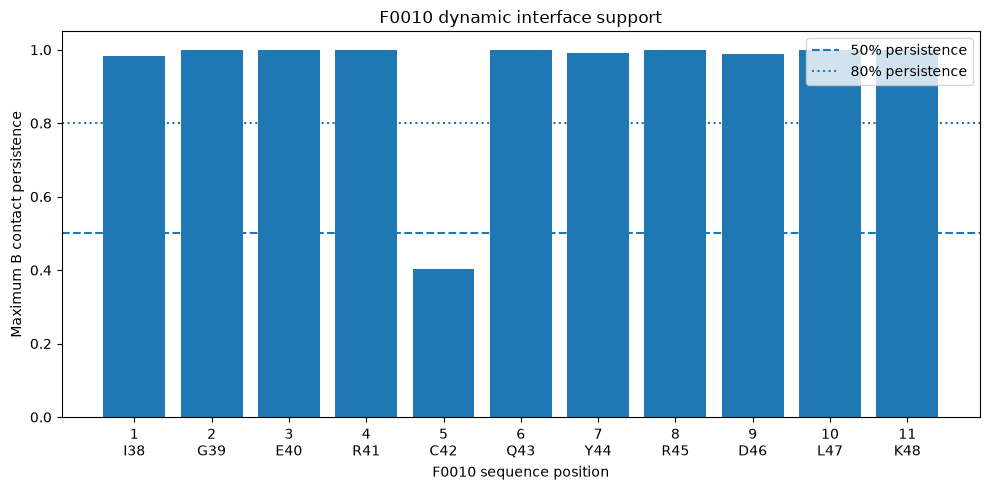

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    f0010_dynamic_df["sequence_position_1based"],
    f0010_dynamic_df["max_contact_persistence"],
)

plt.axhline(
    PERSISTENCE_THRESHOLD,
    linestyle="--",
    label="50% persistence",
)

plt.axhline(
    HIGH_PERSISTENCE_THRESHOLD,
    linestyle=":",
    label="80% persistence",
)

plt.xticks(
    f0010_dynamic_df["sequence_position_1based"],
    [
        f"{row.sequence_position_1based}\n{row.aa}{int(row.resid)}"
        for row in f0010_dynamic_df.itertuples()
    ],
)

plt.ylim(0, 1.05)
plt.xlabel("F0010 sequence position")
plt.ylabel("Maximum B contact persistence")
plt.title("F0010 dynamic interface support")
plt.legend()
plt.tight_layout()

plt.savefig(
    REPORT_DIR / "F0010_dynamic_persistence_profile.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 13. F0010 RMSF profile

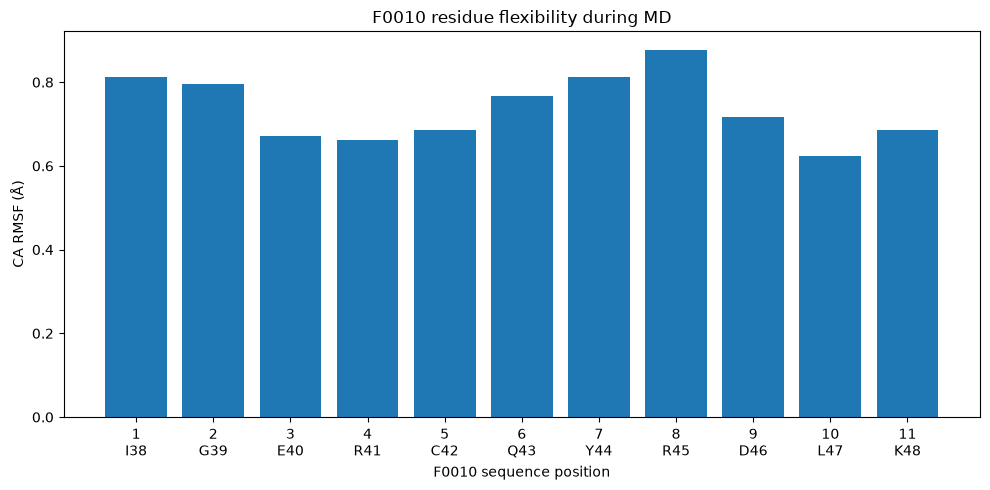

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    f0010_dynamic_df["sequence_position_1based"],
    f0010_dynamic_df["CA_RMSF_A"],
)

plt.xticks(
    f0010_dynamic_df["sequence_position_1based"],
    [
        f"{row.sequence_position_1based}\n{row.aa}{int(row.resid)}"
        for row in f0010_dynamic_df.itertuples()
    ],
)

plt.xlabel("F0010 sequence position")
plt.ylabel("CA RMSF (Å)")
plt.title("F0010 residue flexibility during MD")
plt.tight_layout()

plt.savefig(
    REPORT_DIR / "F0010_RMSF_profile.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 14. F0010 contact partners on chain B

In [14]:
f0010_contact_df = contact_df[
    contact_df["D_resid"].between(
        F0010_START_RESID,
        F0010_END_RESID,
    )
].copy()

f0010_contact_df = (
    f0010_contact_df
    .sort_values(
        [
            "D_resid",
            "persistence",
        ],
        ascending=[True, False],
    )
)

f0010_contact_df.to_csv(
    TABLE_DIR / "F0010_chainB_contact_partners.csv",
    index=False,
)

print(
    "Unique chain-B residues contacting F0010:",
    f0010_contact_df["B_resid"].nunique(),
)

print(
    "Persistent F0010 contacts >=50%:",
    (
        f0010_contact_df["persistence"]
        >= PERSISTENCE_THRESHOLD
    ).sum(),
)

display(
    f0010_contact_df.head(50)
)


Unique chain-B residues contacting F0010: 28
Persistent F0010 contacts >=50%: 34


,B_resname,B_resid,D_resname,D_resid,frames_in_contact,n_frames,persistence,persistence_percent,mean_min_distance_A,persistent_50pct
30,HIS,409,ILE,38,491,500,0.982,98.2,3.658466,True
75,LEU,17,ILE,38,276,500,0.552,55.2,4.042069,True
79,GLN,408,ILE,38,219,500,0.438,43.8,4.092549,False
120,ASN,12,ILE,38,9,500,0.018,1.8,4.262755,False
138,THR,15,ILE,38,1,500,0.002,0.2,4.349710,False
140,SER,11,ILE,38,1,500,0.002,0.2,4.424400,False
19,THR,15,GLY,39,499,500,0.998,99.8,3.541015,True
56,SER,11,GLY,39,429,500,0.858,85.8,3.863973,True
87,ASN,12,GLY,39,123,500,0.246,24.6,4.056063,False
97,LEU,17,GLY,39,53,500,0.106,10.6,4.083800,False


## 15. Persistent F0010 contact network table

In [15]:
persistent_f0010_contacts_df = (
    f0010_contact_df[
        f0010_contact_df["persistence"]
        >= PERSISTENCE_THRESHOLD
    ]
    .copy()
)

persistent_f0010_contacts_df.to_csv(
    TABLE_DIR
    / "F0010_persistent_contacts_50pct.csv",
    index=False,
)

display(
    persistent_f0010_contacts_df
)


,B_resname,B_resid,D_resname,D_resid,frames_in_contact,n_frames,persistence,persistence_percent,mean_min_distance_A,persistent_50pct
30,HIS,409,ILE,38,491,500,0.982,98.2,3.658466,True
75,LEU,17,ILE,38,276,500,0.552,55.2,4.042069,True
19,THR,15,GLY,39,499,500,0.998,99.8,3.541015,True
56,SER,11,GLY,39,429,500,0.858,85.8,3.863973,True
9,THR,15,GLU,40,500,500,1.000,100.0,3.448216,True
23,LYS,13,GLU,40,496,500,0.992,99.2,3.037456,True
39,SER,11,GLU,40,482,500,0.964,96.4,3.646513,True
66,ASN,12,GLU,40,385,500,0.770,77.0,4.075508,True
0,ASP,355,ARG,41,500,500,1.000,100.0,2.748417,True
11,PHE,357,ARG,41,500,500,1.000,100.0,3.475767,True


## 16. F0010 contact-persistence heatmap

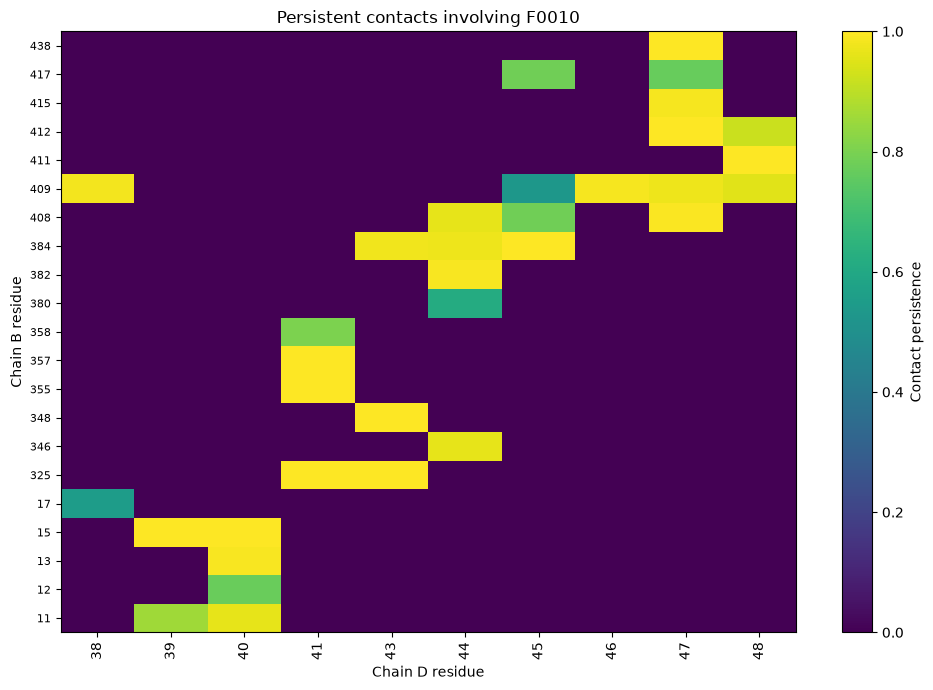

In [16]:
if not persistent_f0010_contacts_df.empty:
    heat = persistent_f0010_contacts_df.pivot_table(
        index="B_resid",
        columns="D_resid",
        values="persistence",
        fill_value=0.0,
        aggfunc="max",
    )

    plt.figure(figsize=(10, 7))
    plt.imshow(
        heat.values,
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=1,
    )

    plt.colorbar(
        label="Contact persistence"
    )

    plt.xticks(
        range(len(heat.columns)),
        heat.columns,
        rotation=90,
    )

    plt.yticks(
        range(len(heat.index)),
        heat.index,
        fontsize=8,
    )

    plt.xlabel("Chain D residue")
    plt.ylabel("Chain B residue")
    plt.title("Persistent contacts involving F0010")
    plt.tight_layout()

    plt.savefig(
        REPORT_DIR
        / "F0010_persistent_contact_heatmap.png",
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()


## 17. Build a simple multi-evidence residue score

In [17]:
# This score is descriptive, not a physical energy.
# It combines normalized dynamic persistence and FoldX hotspot evidence.

if integrated_df is not None:
    score_df = integrated_df.copy()

    score_df["dynamic_component"] = (
        score_df["max_contact_persistence"]
        .clip(0, 1)
    )

    if score_df["foldx_ddG_kcal_mol"].notna().any():
        ddg = score_df["foldx_ddG_kcal_mol"].copy()

        ddg_min = ddg.min(skipna=True)
        ddg_max = ddg.max(skipna=True)

        if (
            np.isfinite(ddg_min)
            and np.isfinite(ddg_max)
            and ddg_max > ddg_min
        ):
            score_df["foldx_component"] = (
                (ddg - ddg_min)
                / (ddg_max - ddg_min)
            )
        else:
            score_df["foldx_component"] = 0.0
    else:
        score_df["foldx_component"] = 0.0

    score_df["foldx_component"] = (
        score_df["foldx_component"]
        .fillna(0.0)
    )

    score_df["combined_evidence_score"] = (
        0.5 * score_df["dynamic_component"]
        + 0.5 * score_df["foldx_component"]
    )

    score_df.to_csv(
        TABLE_DIR
        / "combined_dynamic_foldx_residue_score.csv",
        index=False,
    )

    display(
        score_df.sort_values(
            "combined_evidence_score",
            ascending=False,
        ).head(30)
    )
else:
    score_df = None
    print(
        "Combined evidence score skipped because FoldX data is unavailable."
    )


,resid,resname,max_contact_persistence,mean_contact_persistence,n_partner_residues,chain,dynamic_contact_support,CA_RMSF_A,foldx_ddG_kcal_mol,is_foldx_hotspot,is_md_persistent,is_md_very_persistent,evidence_class,dynamic_component,foldx_component,combined_evidence_score
78,39,GLY,0.998,0.552000,4,D,very_persistent,0.794678,5.87659,True,True,True,FoldX_hotspot_and_MD_persistent,0.998,1.000000,0.999000
80,41,ARG,1.000,0.644333,6,D,very_persistent,0.661158,5.73455,True,True,True,FoldX_hotspot_and_MD_persistent,1.000,0.965586,0.982793
67,26,LEU,0.990,0.474667,9,D,very_persistent,1.114712,4.15852,True,True,True,FoldX_hotspot_and_MD_persistent,0.990,0.583736,0.786868
76,37,TYR,0.822,0.453500,4,D,very_persistent,0.853910,4.64586,True,True,True,FoldX_hotspot_and_MD_persistent,0.822,0.701812,0.761906
64,23,ILE,1.000,0.720000,4,D,very_persistent,0.999830,3.65614,True,True,True,FoldX_hotspot_and_MD_persistent,1.000,0.462017,0.731008
86,47,LEU,1.000,0.650222,9,D,very_persistent,0.623343,3.54371,True,True,True,FoldX_hotspot_and_MD_persistent,1.000,0.434777,0.717388
83,44,TYR,0.992,0.491600,10,D,very_persistent,0.811859,3.37068,True,True,True,FoldX_hotspot_and_MD_persistent,0.992,0.392854,0.692427
59,13,TYR,1.000,0.522000,2,D,very_persistent,0.852956,3.32989,True,True,True,FoldX_hotspot_and_MD_persistent,1.000,0.382971,0.691486
73,33,CYS,1.000,0.767500,4,D,very_persistent,0.762207,2.91303,True,True,True,FoldX_hotspot_and_MD_persistent,1.000,0.281972,0.640986
58,12,GLY,0.960,0.650000,4,D,very_persistent,1.074956,2.88259,True,True,True,FoldX_hotspot_and_MD_persistent,0.960,0.274597,0.617298


## 18. Interpretation categories

The notebook uses the following qualitative categories:

```text
FoldX hotspot + high MD persistence
    → strongest cross-method computational support

FoldX hotspot + low MD persistence
    → energetically important in the static model,
      but dynamically less stable in this trajectory

non-hotspot + high MD persistence
    → structural contact maintained dynamically,
      but not strongly energetic by FoldX alanine scanning

low FoldX + low persistence
    → weakest current interface support
```

This categorisation is deliberately conservative and descriptive.


## 19. Automatic summary

In [18]:
n_f0010_md_persistent = int(
    f0010_dynamic_df["is_md_persistent"]
    .sum()
)

n_f0010_positions = len(
    f0010_dynamic_df
)

f0010_persistent_fraction = (
    n_f0010_md_persistent
    / n_f0010_positions
)

n_f0010_contacts_persistent = len(
    persistent_f0010_contacts_df
)

if hotspot_df is not None:
    n_f0010_foldx_hotspots = int(
        f0010_dynamic_df["is_foldx_hotspot"]
        .fillna(False)
        .sum()
    )

    n_f0010_dual = int(
        (
            f0010_dynamic_df["is_md_persistent"]
            & f0010_dynamic_df["is_foldx_hotspot"].fillna(False)
        ).sum()
    )
else:
    n_f0010_foldx_hotspots = None
    n_f0010_dual = None

summary = {
    "run_source": RUN_LABEL,
    "F0010_sequence": F0010_SEQUENCE,
    "F0010_chain": CHAIN_D,
    "F0010_residue_interval": f"{F0010_START_RESID}-{F0010_END_RESID}",
    "n_F0010_positions": n_f0010_positions,
    "n_F0010_MD_persistent_positions": n_f0010_md_persistent,
    "F0010_MD_persistent_fraction": f0010_persistent_fraction,
    "n_F0010_persistent_contacts": n_f0010_contacts_persistent,
    "n_F0010_FoldX_hotspots": n_f0010_foldx_hotspots,
    "n_F0010_dual_FoldX_MD_support": n_f0010_dual,
    "foldx_file_used": str(HOTSPOT_FILE) if HOTSPOT_FILE else None,
}

summary_df = pd.DataFrame([summary])

summary_df.to_csv(
    TABLE_DIR / "07c_summary_metrics.csv",
    index=False,
)

display(summary_df.T)


,0
run_source,production_1ns
F0010_sequence,IGERCQYRDLK
F0010_chain,D
F0010_residue_interval,38-48
n_F0010_positions,11
n_F0010_MD_persistent_positions,10
F0010_MD_persistent_fraction,0.909091
n_F0010_persistent_contacts,34
n_F0010_FoldX_hotspots,6
n_F0010_dual_FoldX_MD_support,6


## 20. Generate final report

In [22]:
if hotspot_df is not None:
    dual_support_rows = f0010_dynamic_df[
        f0010_dynamic_df["is_md_persistent"]
        & f0010_dynamic_df["is_foldx_hotspot"].fillna(False)
    ]

    dual_text = "\n".join([
        (
            f"- D:{row.aa}{int(row.resid)} "
            f"(position {int(row.sequence_position_1based)}): "
            f"MD persistence={row.max_contact_persistence:.2f}, "
            f"FoldX ddG={row.foldx_ddG_kcal_mol:.3f} kcal/mol"
        )
        for row in dual_support_rows.itertuples()
    ])

    if not dual_text:
        dual_text = "- none"

else:
    dual_text = "- FoldX hotspot file not available"


top_f0010_contacts_text = "\n".join([
    (
        f"- B:{row.B_resname}{int(row.B_resid)} "
        f"- D:{row.D_resname}{int(row.D_resid)}: "
        f"{row.persistence_percent:.1f}%"
    )
    for row in persistent_f0010_contacts_df.head(15).itertuples()
])

if not top_f0010_contacts_text:
    top_f0010_contacts_text = "- none"


report = f"""# 07c - EGF–EGFR MD Interface Persistence and F0010 Source-Region Analysis

## Source
- MD run: {RUN_LABEL}
- F0010 reference sequence: {F0010_SEQUENCE}
- F0010 source region in full EGF chain D: {F0010_START_RESID}-{F0010_END_RESID}
- MD persistent-contact threshold: {PERSISTENCE_THRESHOLD:.0%}
- Historical FoldX BuildModel design-anchor threshold: {FOLDX_HOTSPOT_THRESHOLD:.1f} kcal/mol

## F0010 source-region persistence within full EGF
- Positions analysed: {n_f0010_positions}
- MD-persistent positions: {n_f0010_md_persistent}
- MD-persistent fraction: {f0010_persistent_fraction:.3f}
- Persistent EGFR–EGF contacts involving residues D38–48: {n_f0010_contacts_persistent}

## FoldX-derived information
- FoldX file: {HOTSPOT_FILE}
- D38–48 positions classified as historical BuildModel design anchors: {n_f0010_foldx_hotspots}
- D38–48 positions supported by both historical FoldX-derived information and MD persistence: {n_f0010_dual}

## D38–48 residues with combined FoldX-derived/MD support
{dual_text}

## Top persistent EGFR contacts involving the D38–48 EGF region
{top_f0010_contacts_text}

## Interpretation
This notebook integrates FoldX-derived energetic information with contact
persistence from the 1 ns extracellular EGF–EGFR molecular-dynamics trajectory.

Residues D38–48 correspond to the source region from which F0010 was extracted.
In this notebook these residues are analysed while they remain part of the full
EGF chain D. Therefore, the results support persistence of the F0010 source
region within the EGF–EGFR complex; they do not constitute MD validation of
F0010 as an autonomous isolated peptide.

Direct molecular-dynamics assessment of the extracted F0010 peptide is performed
subsequently in 07d_Selected_Peptide_MD_Comparison.ipynb.

Agreement between FoldX-derived information and MD persistence represents
computational convergence and does not constitute experimental validation of
binding, affinity, inhibition or biological activity.
"""


REPORT_PATH = (
    REPORT_DIR
    / "07c_MD_hotspot_interface_validation_report.md"
)

REPORT_PATH.write_text(
    report,
    encoding="utf-8",
)

print(report)
print("Report:", REPORT_PATH.resolve())


# 07c - EGF–EGFR MD Interface Persistence and F0010 Source-Region Analysis

## Source
- MD run: production_1ns
- F0010 reference sequence: IGERCQYRDLK
- F0010 source region in full EGF chain D: 38-48
- MD persistent-contact threshold: 50%
- Historical FoldX BuildModel design-anchor threshold: 1.5 kcal/mol

## F0010 source-region persistence within full EGF
- Positions analysed: 11
- MD-persistent positions: 10
- MD-persistent fraction: 0.909
- Persistent EGFR–EGF contacts involving residues D38–48: 34

## FoldX-derived information
- FoldX file: outputs/energetic_hotspots.csv
- D38–48 positions classified as historical BuildModel design anchors: 6
- D38–48 positions supported by both historical FoldX-derived information and MD persistence: 6

## D38–48 residues with combined FoldX-derived/MD support
- D:G39 (position 2): MD persistence=1.00, FoldX ddG=5.877 kcal/mol
- D:R41 (position 4): MD persistence=1.00, FoldX ddG=5.735 kcal/mol
- D:Q43 (position 6): MD persistence=1.00, FoldX ddG=2

# 21. How to interpret the result

The most important outputs are:

```text
tables/
├── dynamic_interface_residue_support.csv
├── dynamic_interface_with_rmsf.csv
├── FoldX_MD_integrated_residue_validation.csv
├── F0010_MD_dynamic_support.csv
├── F0010_chainB_contact_partners.csv
├── F0010_persistent_contacts_50pct.csv
├── combined_dynamic_foldx_residue_score.csv
└── 07c_summary_metrics.csv
```

and:

```text
reports/
├── F0010_dynamic_persistence_profile.png
├── F0010_RMSF_profile.png
├── F0010_persistent_contact_heatmap.png
└── 07c_MD_hotspot_interface_validation_report.md
```

---

## Scientific next step

After this notebook there are two possible directions:

### A. Extend the extracellular EGF–EGFR MD

If longer-timescale characterization is required, the same extracellular
EGF–EGFR B–D system can be extended beyond the current 1 ns prototype.
The present 1 ns trajectory should not be interpreted as demonstrating
long-timescale conformational convergence.

### B. Move to selected peptide complexes

If the extracellular EGF–EGFR interface shows sufficient short-timescale persistence and the D38–48 source region is clearly represented in the persistent contact network, use the next notebook to compare:
```text
F0010
CF_06
CF_02
```

in bound-state MD.

The next notebook performs direct bound-state MD of the extracted F0010 peptide and the selected counterfactual peptides. This is conceptually distinct from the present 07c analysis, in which residues D38–48 are still part of the full EGF chain.
